# Assignment 2: Language Modelling (TA: Harshit, Sudharshan)

The goal of this assignment is to model city names using character-level language models.

Please make a copy of this notebook (locally or on Colab). Ensure you adhere to the guidelines and submission instructions (mentioned below) for attempting and submitting the assignment.


### Guidelines for Attempting the Assignment

1. Write your logic in the cells **ONLY** which have the comment `# ADD YOUR CODE HERE`, between the `# BEGIN CODE` and `# END CODE` comments. These cells are also demarcated by the special start (`## ==== BEGIN EVALUATION PORTION`) and end (`## ==== END EVALUATION PORTION`) comments. Do **NOT** remove any of these comments from the designated cells, otherwise your assignment will not be evaluated correctly.

2. Write your code **ONLY** in the cells designated for auto-evaluation, between the `# BEGIN CODE` and `# END CODE` comments. Please don't write any extra code or comments anywhere else.

3. All imports that should be necessary are already provided as part of the notebook. You should **NOT** import any new libraries, otherwise your assignment will not be graded.

4. You need to install the libraries/imports used in this notebook yourself. Its recommended to use python version between 3.9 and 3.11 to attempt this assignment.

5. **If you encounter any errors in the supporting cells during execution, contact the respective TAs.**

6. **Please read the function docs and comments carefully**. They provide specific instructions and examples for implementing each function. Follow these instructions precisely - neither oversimplify nor overcomplicate your implementations. Deviating from the provided implementation guidelines may result in lost marks.

7. **Important**: Use of AI-assistive technologies such as ChatGPT or GitHub CoPilot is not permitted for this assignment. Ensure that all attempts are solely your own. Not following this rule can incur a large penalty, including but not limited to scoring a zero for this assignment.

## Submission Instructions

Note that your assignment will be marked based on the results obtained by functions implemented by you. Do not change the print statements having `EVALUATION` as they are used for auto-evaluation.

You'd need to submit the following files:

  * Save this `.ipynb` to your drive, complete the required code blocks and run the notebook.

  * After completing this assignment, download the notebook as`.py`. Name it as `assignment2.py`.

  *   The files associated with FNN and RNN models i.e. `model.pt`, `vocab.pt` and `loss.json` will be downloaded and saved in folders with names `fnn` and `rnn` respectively, and these will be contained within folder `SAPname_SRno`. Zip this folder along with the `.py` file, save it as `SAPname_SRno` and upload on MS Teams. The directory can be summarised as follows:

```
SAPname_SRno.zip
  └──SAPname_SRno
     │   assignment2.py   
     └───fnn
     │   │   model.pt
     │   │   vocab.pt
     │   │   loss.json
     │
     └───rnn
         │   model.pt
         │   vocab.pt
         │   loss.json

```

Because submissions are auto-graded, please ensure that the naming of the files is consistent with the instructions.

### Marks Distribution

- Unigram: 15
- Bigram: 15
- Trigram: 15
- Neural N-gram LM: 25
- RNN LM: 30

In the cell below, replace `SAPName` with your name as per SAP record, and `SRNo` with the last 5 digits of your IISc SR number. For example, IISc student with SAP name Twyla Linda (SR no - 04-03-00-10-22-20-1-15329) would use:

```python
STUDENT_SAP_NAME  = "Twyla Linda"
STUDENT_SR_NUMBER = "15329"
```

In [ ]:
STUDENT_SAP_NAME  = "Abha Singh Saradar"
STUDENT_SR_NUMBER = "27086"

# Read and Preprocess Data

In [ ]:
pip install torch==2.3.0 torchtext==0.18

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import math

import random
from collections import Counter, defaultdict
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader

/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


Please note that we may change the contents of the following four files when we rerun your code, so please make sure that your solution is not specifically engineered to just these names.

In [ ]:
# Download the training and validation datasets
!wget -O train_data.csv "https://docs.google.com/spreadsheets/d/11XH5kidyglP-zlP2AjAxfD0Brpu4hmBZP-Uuy9VfjE8/export?format=csv"
!wget -O valid_data.csv "https://docs.google.com/spreadsheets/d/1cxkItpdzz0yWc4Tk_1oA4UO6_oUy2cyF4mW3R1D9G9k/export?format=csv"

# Download the text for evaluation
!wget -O eval_prefixes.txt "https://drive.google.com/uc?export=download&id=13WPjditzqRrBhioMT2yWRxj6Ympnt-_P"
!wget -O eval_sequences.txt "https://drive.google.com/uc?export=download&id=1A_z46aBFyyw7q0uv7oGI4G-FtrNmUutN"

--2026-03-12 17:01:11--  https://docs.google.com/spreadsheets/d/11XH5kidyglP-zlP2AjAxfD0Brpu4hmBZP-Uuy9VfjE8/export?format=csv
Resolving docs.google.com (docs.google.com)... 142.250.101.139, 142.250.101.101, 142.250.101.102, ...
Connecting to docs.google.com (docs.google.com)|142.250.101.139|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://doc-00-14-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/6oi2psi2e4h8977se7drm00hd8/1773334870000/118234330873002746631/*/11XH5kidyglP-zlP2AjAxfD0Brpu4hmBZP-Uuy9VfjE8?format=csv [following]
--2026-03-12 17:01:11--  https://doc-00-14-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/6oi2psi2e4h8977se7drm00hd8/1773334870000/118234330873002746631/*/11XH5kidyglP-zlP2AjAxfD0Brpu4hmBZP-Uuy9VfjE8?format=csv
Resolving doc-00-14-sheets.googleusercontent.com (doc-00-14-sheets.googleusercontent.com)... 74.125.137.132, 2607:f8b0:4023:c03::84
Connecting to doc-00-14-sheets.googleuserc

In [ ]:
## Please do not change anything in this code block.

def read_dataframe(ds_type):
    """
    Args:
        ds_type [str] :  dataset type (train or valid)

    Returns:
        df [pandas dataframe]
    """

    df = pd.read_csv(f"/content/{ds_type}_data.csv", header=0)
    print(df)
    df = df[~df['Name'].isna()]
    df['Name'] = df['Name'].astype(str)
    return df

# Load the training and validation datasets
train_data = read_dataframe("train")
validation_data = read_dataframe("valid")

# Read files containing prefixes and character sequences for evaluation
with open('eval_prefixes.txt', 'r') as file:
    eval_prefixes = []
    for line in file:
        eval_prefixes.append(line.strip().split(" "))

with open('eval_sequences.txt', 'r') as file:
    eval_sequences = []
    for line in file:
        eval_sequences.append(line.strip().split(" "))

print(f"Length of training data: {len(train_data)}\nLength of validation data: {len(validation_data)}")

                Name
0             susari
1             belari
2            bandora
3       tummalapenta
4          majhgawan
...              ...
3395     parappukara
3396      morubagalu
3397          dasaut
3398  pullalacheruvu
3399         bhavani

[3400 rows x 1 columns]
            Name
0      enamadala
1     aurangabad
2     mustafabad
3         kalyan
4        kadiyam
...          ...
1129  madhavaram
1130     shahpur
1131     bimawan
1132     jalgaon
1133   virapandi

[1134 rows x 1 columns]
Length of training data: 3400
Length of validation data: 1134


In [ ]:
## Please do not change anything in this code block.

START = "<s>"   # Start-of-name token
END = "</s>"    # End-of-name token
UNK = "<unk>"   # token representing out of unknown (or out of vocabulary) tokens
vocab_from_ascii = False

def build_vocab(names):
    """
    Builds a vocabulary given a list of names

    Args:
        names [list[str]]: list of names

    Returns:
        vocab [torchtext.vocab]: vocabulary based on the names

    """

    if vocab_from_ascii:
        char_counts = {chr(i):i for i in range(128)}
    else:
        char_counts = Counter("".join(names))

    vocab = build_vocab_from_iterator(
                    char_counts,
                    specials=[UNK, START, END], #adding special tokens to the vocabulary
                    min_freq=1
                )
    vocab.set_default_index(vocab[UNK])
    return vocab


def tokenize_name(name):
    """
    Tokenise the name i.e. break a name into list of characters

    Args:
        name [str]: name to be tokenized

    Returns:
        list of characters
    """

    return list(str(name))


def process_data_for_input(data_iter, vocab):
    """
    Processes data for input: Breaks names into characters,
    converts out of vocabulary tokens to UNK and
    appends END token at the end of every name

    Args:
        data_iter: data iterator consisting of names
        vocab: vocabulary

    Returns:
        data_iter [list[list[str]]]: list of names, where each name is a
                                list of characters and is appended with
                                START and END tokens

    """

    vocab_set = set(vocab.get_itos())
    # convert Out Of Vocabulary (OOV) tokens to UNK tokens
    data_iter = [[char if char in vocab_set else UNK
                        for char in tokenize_name(name)] for name in data_iter]
    data_iter = [[START] + name + [END] for name in data_iter]
    return data_iter


def get_tokenised_text_and_vocab(ds_type, vocab=None):
    """
    Reads input data, tokenizes it, builds vocabulary (if unspecified)
    and outputs tokenised list of names (which in turn is a list of characters)

    Args:
        ds_type [str]: Type of the dataset (e.g., train, validation, test)
        vocab [torchtext.vocab]: vocabulary;
                                 If vocab is None, the function will
                                 build the vocabulary from input text.
                                 If vocab is provided, it will tokenize name
                                 according to the vocab, replacing any tokens
                                 not part of the vocab with UNK token.

    Returns:
        data_iter: data iterator for tokenized names
        vocab: vocabulary
    """

    # read the 'Name' column of the dataframe
    if ds_type=='train':
        data_iter = train_data['Name']
    elif ds_type=='valid':
        data_iter = validation_data['Name']
    else:
        data_iter = test_data['Name']

    # build vocab from input data, if vocab is unspecified
    if vocab is None:
        vocab = build_vocab(data_iter)

    # convert OOV chars to UNK, append START and END token to each name
    data_iter = process_data_for_input(data_iter, vocab)

    return data_iter, vocab

Let's look at some examples from the training set

In [ ]:
# Look at some random examples from the training set
examples = ", ".join(random.sample(list(train_data['Name']), 5))
f"Examples from the training set: {examples}"

'Examples from the training set: gundlupet, chennai, vannivedu, janglot, mirzapur'

In [ ]:
# ==== BEGIN EVALUATION PORTION

"""choose your hyperparameter and see the difference in performance"""

# CHANGE THE None VALUES TO YOUR DESIRED VALUES

# BEGIN CODE : stat.namelength
# ADD YOUR CODE HERE

MAX_NAME_LENGTH = 30 # maximum length of names for generation

# END CODE
# ==== END EVALUATION PORTION

In [ ]:
# Get data iterator and build vocabulary from input text

train_text, vocab = get_tokenised_text_and_vocab(ds_type='train')
validation_text, _ = get_tokenised_text_and_vocab(ds_type='valid', vocab=vocab)

# Check the size of vocabulary
vocab_size = len(vocab.get_stoi())
print(vocab_size)
print(train_text)

29
[['<s>', 's', 'u', 's', 'a', 'r', 'i', '</s>'], ['<s>', 'b', 'e', 'l', 'a', 'r', 'i', '</s>'], ['<s>', 'b', 'a', 'n', 'd', 'o', 'r', 'a', '</s>'], ['<s>', 't', 'u', 'm', 'm', 'a', 'l', 'a', 'p', 'e', 'n', 't', 'a', '</s>'], ['<s>', 'm', 'a', 'j', 'h', 'g', 'a', 'w', 'a', 'n', '</s>'], ['<s>', 'k', 'a', 'p', 'a', 's', 'i', 'a', 'w', 'a', 'n', '</s>'], ['<s>', 'g', 'u', 'l', 'b', 'a', 'r', 'g', 'a', '</s>'], ['<s>', 't', 'a', 'u', 'l', 'a', 'h', 'a', '</s>'], ['<s>', 'k', 'i', 'r', 'a', 'n', 'u', 'r', '</s>'], ['<s>', 'k', 'h', 'o', 'k', 'h', 'a', '</s>'], ['<s>', 'k', 'a', 'l', 'a', 'd', 'g', 'i', '</s>'], ['<s>', 'm', 'a', 'l', 'l', 'a', 's', 'a', 'm', 'u', 'd', 'r', 'a', 'm', '</s>'], ['<s>', 'b', 'a', 'l', 'v', 'a', 'd', 'i', '</s>'], ['<s>', 'b', 'a', 'g', 'a', 'u', 'r', 'a', '</s>'], ['<s>', 'm', 'a', 'd', 'a', 't', 't', 'u', 'k', 'k', 'u', 'l', 'a', 'm', '</s>'], ['<s>', 's', 'i', 'l', 'a', 'd', 'o', 'n', '</s>'], ['<s>', 'c', 'h', 'a', 'r', 'i', 'p', 'a', 'r', 'a', '</s>'], ['

In [ ]:
print(vocab.get_itos())

['<unk>', '<s>', '</s>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
# Standardizing name, prefix
def is_name(tokens):
    return len(tokens) >= 2 and tokens[0] == START and tokens[-1] == END and not START in tokens[1:-1] and not END in tokens[1:-1]
def is_prefix(tokens):
    return tokens is None or (len(tokens) >= 1 and tokens[0] == START and not START in tokens[1:] and not END in tokens[1:])

# Start token is excluded in the calculation of length of name/prefix
def get_name_len(name):
    return len(name) - 2
def get_prefix_len(prefix):
    return 0 if prefix is None else len(prefix) - 1

# Module 1: N-gram Language Modelling

Now it's time to implement an [n-gram language model](https://web.stanford.edu/~jurafsky/slp3/3.pdf).

The only differnce between different language models in this notebook is the way the probability of the next charecter is estimated given previous charecters. Knowing the conditional probability (and the detail that all sequences begin with a start token), we can calculate the probability of a name, perplexity of a dataset, generate new names and many more. Hence, most utility functions are implemented in the base class while calculating the conditional probability is done in the corresponding subclass.

One edge case you will need to handle is that you don't have $n-1$ prior characters at the beginning of the text.  One way to do this is by appending the `START` token $n-1$ times at the start of the name, when implementing an $n$-gram model. You may choose whichever method you like to handle this case as long as you produce a valid probability distribution (one that sums to one).

**Generating names**

To generate from a language model, we can sample one char at a time conditioning on the chars we have generated so far.

In fact there are many strategies to get better-sounding samples, such as only sampling from the top-k chars or sharpening the distribution with a temperature.  You can read more about sampling from a language model in [this](https://arxiv.org/pdf/1904.09751.pdf) paper.


We will now implement N-gram models with $N=1$ (unigram), $N=2$ (bigram), and $N=3$ (trigram).

**Utility Functions**

Implement the utility functions `get_unigram_counts`, `get_bigram_counts` and `get_trigram_counts`. You can use these functions while implementing n-gram models.

**Defining perplexity**

Given a dataset $\chi$ containing sequences of tokens and a language model $P$, the perplexity is given by
$$\exp(\frac{1}{\sum_{x \in \chi}|x|} \sum_{x \in χ}-\log(P(x)))$$

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implementation of the n-gram language models.
All other n-gram models (unigram, bigram, etc.) would follow the same skeleton.
"""

class NGramLanguageModel(object):
    def __init__(self, train_text):
        """
        To be overriden by the subclass. Initialise and train the model with train_text.

        Args:
            train_text [list of list]: list of tokenised names

        Returns:
            -
        """
        for name in train_text:
            assert is_name(name)

    def get_next_char_probabilities(self, prefix= None):
        """
        To be overriden by the subclass. Returns a probability distribution over all chars in the vocabulary.
        Probability distribution should sum to one.
        Input:
            prefix: List[tokens] or None, if list, begins with START token

        Returns:
            P: dict[key:token,value:probability of token given prefix]
        """

        assert is_prefix(prefix)


    def get_name_log_probability(self, name):
        """
        Calculates the log probability of name according to the language model

        Args:
            name [list]: list of tokens

        Returns:
            log_prob [float]: Log probability of the given name
        """
        assert is_name(name), f"Input to get_name_log_probability {name} is not a name"
        # BEGIN CODE : ngramlm.name_log_probability
        # ADD YOUR CODE HERE

        log_prob = 0.0

        for i in range(1, len(name)):
            prefix = name[:i]
            probs = self.get_next_char_probabilities(prefix)
            char = name[i]

            prob = probs.get(char, 0.0)
            if prob == 0.0:
                return float('-inf')

            log_prob += math.log(prob)

        return log_prob


        # END CODE



    def get_perplexity(self, text):
        """
        Returns the perplexity of the model on a text as a float.

        Args:
            text [list]: a list of string tokens

        Returns:
            perplexity [float]: perplexity of the given text
        """
        for name in text:
            assert is_name(name), f"Input to get_perplexity {name} is not a name"

        # BEGIN CODE : ngramlm.perplexity
        # ADD YOUR CODE HERE

        total_log_prob = 0.0
        total_tokens = 0

        for name in text:
            total_log_prob += self.get_name_log_probability(name)
            total_tokens += len(name)

        if total_tokens == 0:
            return float('inf')

        average_log_prob = total_log_prob / total_tokens

        return math.exp(-average_log_prob)

        # END CODE


    def generate_names(self, k, n=MAX_NAME_LENGTH, prefix=None):
        """
        Given a prefix, generate k names according to the model.
        The default prefix is None.
        You may stop the generation when n tokens have been generated,
        or when you encounter the END token.

        Args:
            k [int]: Number of names to generate
            n [int]: Maximum length (number of tokens) in the generated name
            prefix [list of tokens]: Prefix after which the names have to be generated

        Returns:
            names [list[str]]: list of generated names
        """
        assert is_prefix(prefix), f"Input to generate_names {prefix} is not a prefix"
        assert get_prefix_len(prefix) <= n

        # BEGIN CODE : ngramlm.generate_names
        # ADD YOUR CODE HERE

        names = []
        for _ in range(k):
            current_sequence = list(prefix) if prefix is not None else [START]

            while len(current_sequence) < n:
                probs = self.get_next_char_probabilities(current_sequence)

                if not probs:
                    break

                chars = list(probs.keys())
                p_vals = list(probs.values())

                next_char = random.choices(chars, weights=p_vals, k=1)[0]
                current_sequence.append(next_char)

                if next_char == END:
                    break

            clean_name = "".join([c for c in current_sequence if c not in (START, END)])
            names.append(clean_name)

        return names

        # END CODE

    def get_most_likely_chars(self, prefix, k):
        """
        Given a sequence of characters, outputs k most likely characters after the sequence.

        Args:
            sequence [list[str]]: list of characters
            k [int]: number of most likely characters to return

        Returns:
            chars [list[str]]: *Ordered* list of most likely characters
                        (with charcater at index 0 being the most likely and
                        character at index k-1 being the least likely)

        """
        assert is_prefix(prefix), f"Input to get_most_likely_chars {prefix} is not a prefix"
        # BEGIN CODE : ngramlm.most_likely_chars
        # ADD YOUR CODE HERE

        probs = self.get_next_char_probabilities(prefix)
        sorted_chars = sorted(probs.keys(), key=lambda c: probs[c], reverse=True)
        return sorted_chars[:k]

        # END CODE

# ==== END EVALUATION PORTION

In [ ]:
# ## Please do not change anything in this code block.

def check_validity(model, ngram, is_neural):
    """
    Checks if get_next_char_probabilities returns a valid probability distribution
    """

    if is_neural:
        P = model.get_next_char_probabilities()
        is_valid = validate_probability_distribution(P.values())
        return is_valid
    else:
        prefixes= [
            None,
            [START],
            [START, 's'],
            [START, 's', 't', 'u']
        ]
        valid= True
        for prefix in prefixes:
            valid= valid and validate_probability_distribution(model.get_next_char_probabilities(prefix).values())
        return valid


def validate_probability_distribution(probs):
    """
    Checks if probs is a valid probability distribution
    """
    if not min(probs) >= 0:
        print("Negative value in probabilities")
        return False
    elif not max(probs) <= 1 + 1e-8:
        print("Value larger than 1 in probabilities")
        return False
    elif not abs(sum(probs)-1) < 1e-4:
        print("probabilities do not sum to 1")
        return False
    return True

def check_validity_of_position_specific_probability(model, ngram, is_neural):
    """
    Checks if get_next_char_probabilities returns a valid probability distribution
    """

    if ngram==1 and not is_neural:
        position_distributions = model.get_position_specific_probabilities()
        valid_count = 0
        total_positions = len(position_distributions)

        for pos, char_probs in enumerate(position_distributions, start=1):
            total_prob = sum(char_probs.values())
            if 0.99 <= total_prob <= 1.01:
                valid_count += 1
        return valid_count

    return True

def eval_ngram_model(model, n, ngram, ds, ds_name, eval_prefixes, eval_sequences, num_names=5, is_neural=False):
    """
    Runs evaluations on n-gram models with beam search support
    """
    # (1) Check probability distribution validity
    is_valid = check_validity(model=model, ngram=ngram, is_neural=is_neural)
    print(f'EVALUATION probability distribution is valid: {is_valid}')

    # (2) Check position specific probability distribution validity
    if not is_neural and 1==ngram:
        valid_count = check_validity_of_position_specific_probability(model=model, ngram=ngram, is_neural=is_neural)
        print(f'Total positions which have valid probability distributions: {valid_count}')

    # (3) Evaluate perplexity
    print(f'EVALUATION of {ngram}-gram on {ds_name} perplexity:',
          model.get_perplexity(ds))

    # (4) Generate top-k names using beam search
    generated_names = ", ".join(model.generate_names(n=n,k=num_names))
    print(f'EVALUATION {ngram}-gram TOP {num_names} names: {generated_names}')

    # (5) Generate names with prefixes
    for prefix in eval_prefixes:
        generated_names_with_prefix = ", ".join(model.generate_names(n=n, k=num_names, prefix=prefix))
        prefix_str = ''.join(prefix)
        print(f'EVALUATION {ngram}-gram TOP {num_names} names with prefix "{prefix_str}": {generated_names_with_prefix}')

    # (6) Get most likely characters
    for sequence in eval_sequences:
        most_likely_chars = ", ".join(model.get_most_likely_chars(sequence, k=num_names))
        sequence_str = "".join(sequence)
        print(f"EVALUATION {ngram}-gram top likely chars after '{sequence_str}': {most_likely_chars}")

    # (7) Check KL divergence for unigram
    if ngram==1:
        position_distributions = model.get_position_specific_probabilities(max_position=5)
        position_1_dist = position_distributions[0]
        position_2_dist = position_distributions[1]
        kl_div = model.calculate_kl_divergence_between_positions(position_1_dist, position_2_dist)
        print(f'KL Divergence between position 1 and 2 is: {kl_div:.3f}')



## 1.1 Unigram

In [ ]:
# ==== BEGIN EVALUATION PORTION
def get_unigram_counts(corpus):
    """
    Given a corpus, calculates the unigram counts for each character in the corpus

    Args:
        corpus [list[list[str]]]: list of tokenized characters. Text is appended with END token.

    Returns:
        unigram_counts [dict [key: char, value: count]]:
            dictionary of unigram counts for each character in the corpus
        Example:
        > unigram_counts["c1"] = 5
    """
    for name in corpus:
        assert is_name(name)

    # BEGIN CODE : unigram_count.get_unigram_counts
    # ADD YOUR CODE HERE

    unigram_counts = {}

    for name in corpus:
        for char in name:
            if char != START:
                unigram_counts[char] = unigram_counts.get(char, 0) + 1
    return unigram_counts

    # END CODE


# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implementaion of a Unigram Model without smoothing
"""

class UnigramModel(NGramLanguageModel):
    def __init__(self, train_text):
        """
        Initialise and train the model with train_text.

        Args:
            train_text [list of list]: list of tokenised names
        """
        for name in train_text:
            assert is_name(name)

        # BEGIN CODE : unigrammodel.init
        # ADD YOUR CODE HERE

        super().__init__(train_text)
        self.train_text = train_text
        self.counts = get_unigram_counts(train_text)
        total_tokens = sum(self.counts.values())

        self.vocab = set(char for name in train_text for char in name)
        self.probs = {char: self.counts.get(char, 0) / total_tokens for char in self.vocab}

        # END CODE


    def get_next_char_probabilities(self, prefix= None):
        """
        Return a dictionary of probabilities for each char in the vocabulary

        Returns:
            key: char, value: probability
        """
        assert is_prefix(prefix)

        # BEGIN CODE : unigrammodel.get_next_char_prob
        # ADD YOUR CODE HERE

        return self.probs

        # END CODE


    def get_position_specific_probabilities(self, max_position=5):
        """
        Computes probability distributions for each character in the vocabulary at specific positions in words.

        This method analyzes the training data to calculate the likelihood of each character appearing
        at different positions (1st, 2nd, 3rd, etc.) in words. For example, it determines how often
        'q' appears as the first letter, second letter, and so on.

        Args:
            max_position (int, optional): Maximum number of initial positions in words to analyze.
                For example, if max_position=3, only the first three positions in words will be
                considered. Defaults to 5.

        Returns:
            list[dict]: A list of dictionaries where:
                - The index represents the position (0-based)
                - Each dictionary maps characters to their probabilities at that position
                - Example: [{'a': 0.1, 'b': 0.2, ...}, {'a': 0.15, 'b': 0.1, ...}, ...]
                - The probabilities in each dictionary sum to 1.0

        Example:
            >>> model.get_position_specific_probabilities(2)
            [
                {'a': 0.12, 'b': 0.08, 'c': 0.15, ...},  # Probabilities for first position
                {'a': 0.40, 'b': 0.11, 'c': 0.07, ...}   # Probabilities for second position
            ]
        """


        # BEGIN CODE : unigrammodel.get_position_specific_prob
        # ADD YOUR CODE HERE

        vocab_chars = list(self.probs.keys())

        pos_counts = [{char: 0 for char in vocab_chars} for _ in range(max_position)]
        pos_totals = [0] * max_position

        for name in self.train_text:
            for i in range(min(max_position, len(name) - 1)):
                char = name[i + 1]
                if char in pos_counts[i]:
                    pos_counts[i][char] += 1
                pos_totals[i] += 1

        pos_probs = []
        for i in range(max_position):
            prob_dict = {}
            for char in vocab_chars:
                if pos_totals[i] > 0:
                    prob_dict[char] = pos_counts[i][char] / pos_totals[i]
                else:
                    prob_dict[char] = 0.0
            pos_probs.append(prob_dict)

        return pos_probs

        # END CODE




    def calculate_kl_divergence_between_positions(self, p, q):
        """
        Computes overall KL divergence between two probability distributions.

        Args:
            p [dict]: Probability distribution
            q [dict]: Probability distribution

        Returns:
            kl_divergence [float]: KL(p||q). Returns -1 if the KL divergence is undefined.
        """

        # BEGIN CODE : unigrammodel.kl_divergence
        # ADD YOUR CODE HERE

        p_sum = sum(p.values())
        q_sum = sum(q.values())

        if p_sum == 0 or q_sum == 0:
            return -1.0

        kl_div = 0.0

        all_chars = set(p.keys()).union(set(q.keys()))

        for char in all_chars:
            p_prob = p.get(char, 0.0) / p_sum
            q_prob = q.get(char, 0.0) / q_sum

            if p_prob > 0.0:
                if q_prob == 0.0:
                    return -1.0
                kl_div += p_prob * math.log(p_prob / q_prob)

        return kl_div

        # END CODE

# ==== END EVALUATION PORTION

### Eval

**Note**: For models without smoothing, you may observe perplexity as `inf` if the validation or test set contains characters not seen in the train set
However, this should not happen for models where you implement smoothing.

In [ ]:
## Please do not change anything in this code block.

unigram_model = UnigramModel(train_text)

# Check the perplexity of the unigram model on the train set
print('unigram train perplexity:', unigram_model.get_perplexity(train_text))

unigram train perplexity: 12.778487965091145


In [ ]:
## Please do not change anything in this code block.

eval_ngram_model(model=unigram_model, n = MAX_NAME_LENGTH, ngram=1, ds=validation_text, ds_name='validation', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5)

EVALUATION probability distribution is valid: True
Total positions which have valid probability distributions: 5
EVALUATION of 1-gram on validation perplexity: 12.78170450306323
EVALUATION 1-gram TOP 5 names: srsdnn, ggv, aniivlapuukgr, plseunraotknhtriamnarer, aimakdalaie
EVALUATION 1-gram TOP 5 names with prefix "<s>sh": shlal, shaai, shadpolhmttgiaanga, shnrhsga, shuu
EVALUATION 1-gram TOP 5 names with prefix "<s>na": naamtatikh, naaaarpjaaahknrgliypawadaappa, narapmamua, nalaraoaroruagum, narvtaaob
EVALUATION 1-gram TOP 5 names with prefix "<s>da": daarl, danpg, dapgarnrglavau, dasuoabrbrha, dawnpn
EVALUATION 1-gram TOP 5 names with prefix "<s>ki": kisaaniehr, kiniutsda, kirerbpu, kimpdi, kitacuaanniva
EVALUATION 1-gram TOP 5 names with prefix "<s>ra": raradgo, raadmlln, rakahk, ralhja, rabbahvunkukoarop
EVALUATION 1-gram TOP 5 names with prefix "<s>de": deaa, derjewhntl, dealaba, delm, denaldaoarfakapuoosnhnhshauui
EVALUATION 1-gram TOP 5 names with prefix "<s>ni": nituh, nigobliu

In [ ]:
## Please do not change anything in this code block.
position_distributions = unigram_model.get_position_specific_probabilities(max_position=5)

print("Position-Specific Probabilities:")
for pos, dist in enumerate(position_distributions, start=1):
    # Sort dictionary by character key (a-z, A-Z)
    sorted_dist = {k: round(v, 2) for k, v in sorted(dist.items())}  # Round to 2 decimal places
    print(f"Position {pos}: {sorted_dist}")

Position-Specific Probabilities:
Position 1: {'</s>': 0.0, '<s>': 0.0, 'a': 0.06, 'b': 0.09, 'c': 0.05, 'd': 0.04, 'e': 0.01, 'f': 0.0, 'g': 0.04, 'h': 0.03, 'i': 0.01, 'j': 0.03, 'k': 0.15, 'l': 0.01, 'm': 0.09, 'n': 0.05, 'o': 0.01, 'p': 0.1, 'q': 0.0, 'r': 0.04, 's': 0.09, 't': 0.05, 'u': 0.01, 'v': 0.04, 'w': 0.0, 'x': 0.0, 'y': 0.01, 'z': 0.0}
Position 2: {'</s>': 0.0, '<s>': 0.0, 'a': 0.43, 'b': 0.0, 'c': 0.0, 'd': 0.01, 'e': 0.08, 'f': 0.0, 'g': 0.0, 'h': 0.12, 'i': 0.09, 'j': 0.0, 'k': 0.0, 'l': 0.01, 'm': 0.01, 'n': 0.01, 'o': 0.08, 'p': 0.0, 'q': 0.0, 'r': 0.02, 's': 0.01, 't': 0.01, 'u': 0.1, 'v': 0.0, 'w': 0.0, 'x': 0.0, 'y': 0.0, 'z': 0.0}
Position 3: {'</s>': 0.0, '<s>': 0.0, 'a': 0.1, 'b': 0.01, 'c': 0.01, 'd': 0.07, 'e': 0.01, 'f': 0.0, 'g': 0.02, 'h': 0.03, 'i': 0.06, 'j': 0.01, 'k': 0.03, 'l': 0.11, 'm': 0.05, 'n': 0.13, 'o': 0.01, 'p': 0.01, 'q': 0.0, 'r': 0.14, 's': 0.03, 't': 0.07, 'u': 0.02, 'v': 0.01, 'w': 0.01, 'x': 0.0, 'y': 0.01, 'z': 0.01}
Position 4: {'</s>'

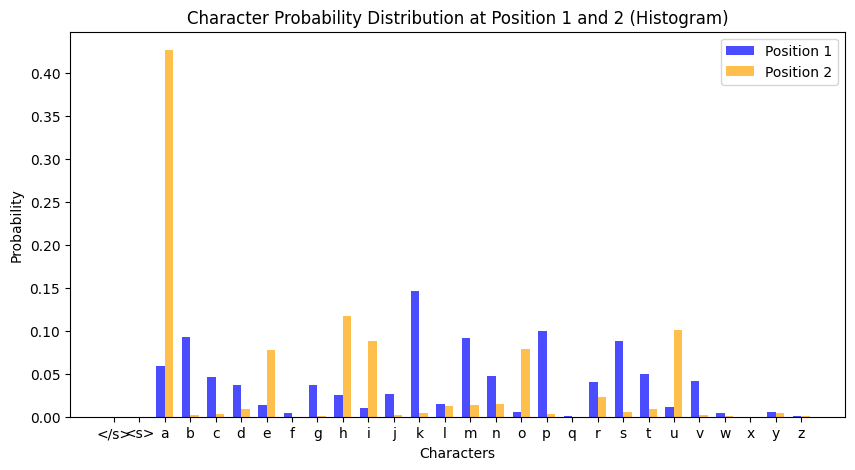

In [ ]:
## Please do not change anything in this code block.
import matplotlib.pyplot as plt
import numpy as np

position_1_distribution = position_distributions[0]
position_2_distribution = position_distributions[1]

sorted_chars = sorted(position_1_distribution.keys())

probs_pos1 = [position_1_distribution[char] for char in sorted_chars]
probs_pos2 = [position_2_distribution[char] for char in sorted_chars]

spacing_factor = 1.5
x = np.arange(len(sorted_chars)) * spacing_factor
width = 0.5

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, probs_pos1, width=width, label="Position 1", color="blue", alpha=0.7)
plt.bar(x + width/2, probs_pos2, width=width, label="Position 2", color="orange", alpha=0.7)
plt.xlabel("Characters")
plt.ylabel("Probability")
plt.title("Character Probability Distribution at Position 1 and 2 (Histogram)")
plt.xticks(ticks=x, labels=sorted_chars)
plt.legend()
plt.show()

### Smoothing

Implement a smoothed version of the unigram model. You may extend the `UnigramModel` class and re-use some of the functions.  For unigram model, you should implement Add-1 smoothing.

You may refer to the lecture slides or [3.5 Smoothing](https://web.stanford.edu/~jurafsky/slp3/3.pdf) for details on different smoothing technqiues.

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implementation of unigram model with Add-1 smoothing.

"""
class SmoothedUnigramModel(UnigramModel):

    def __init__(self, train_text):
        super().__init__(train_text)


    def get_next_char_probabilities(self, prefix= None):
        """
        Return a dictionary of probabilities for each char in the vocabulary
        with Add-1 (Laplace) smoothing.

        Returns:
            key: char, value: probability
        """
        assert is_prefix(prefix)
        # BEGIN CODE : smoothing.smoothunigram
        # ADD YOUR CODE HERE

        vocab_size = len(self.counts)
        total_tokens = sum(self.counts.values())

        smoothed_probs = {}
        for char, count in self.counts.items():
            smoothed_probs[char] = (count + 1) / (total_tokens + vocab_size)

        return smoothed_probs

        # END CODE

# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.

smoothed_unigram_model = SmoothedUnigramModel(train_text)

# Check the perplexity of the smoothed unigram model on the train set
print('smoothed unigram train perplexity:',
      smoothed_unigram_model.get_perplexity(train_text))

smoothed unigram train perplexity: 12.778631244278062


In [ ]:
## Please do not change anything in this code block.

eval_ngram_model(model=smoothed_unigram_model, n = MAX_NAME_LENGTH, ngram=1, ds=validation_text, ds_name='validation', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences,  num_names=5)

EVALUATION probability distribution is valid: True
Total positions which have valid probability distributions: 5
EVALUATION of 1-gram on validation perplexity: 12.781634891257188
EVALUATION 1-gram TOP 5 names: kllirlaav, ao, aujtmey, , niiroii
EVALUATION 1-gram TOP 5 names with prefix "<s>sh": shhvjptoaatnkmaaouliey, shu, shdl, shaoifa, shvav
EVALUATION 1-gram TOP 5 names with prefix "<s>na": naagralt, naaar, nahaam, nakoaigs, na
EVALUATION 1-gram TOP 5 names with prefix "<s>da": daikaakdaratljaaaik, daatprebg, danituvidp, daraknlbcpakaihmag, dajrgtlaltnuauipmpsiai
EVALUATION 1-gram TOP 5 names with prefix "<s>ki": kispdlaua, kiaukeadreiaa, kik, kikaigfaapndeshi, kiua
EVALUATION 1-gram TOP 5 names with prefix "<s>ra": ralbmti, raarleaa, ratna, rariivn, ra
EVALUATION 1-gram TOP 5 names with prefix "<s>de": der, deralp, detriie, deneruamjnrrbak, devmjnnoa
EVALUATION 1-gram TOP 5 names with prefix "<s>ni": niaalasalanl, nihodaagdae, nikrakabg, niatipnnapvovauastaidgkavhiia, niagr
EVALUATI

In [ ]:
# Release models we don't need any more.
del unigram_model
del smoothed_unigram_model

## 1.2 Bigram


In [ ]:
# ==== BEGIN EVALUATION PORTION
def get_bigram_counts(corpus):
    """
    Given a corpus, calculates the bigram counts for each bigram in the corpus.
    The corpus *only* contains END tokens at the end of names.
    You may want to handle the case whhere beginning of the name
    does not have n-1 prior chars.

    Args:
        corpus [list[list[str]]]: list of tokenized text. Text is appended with END token.

    Returns:
        bigram_counts [dict[dict]]:
            nested dictionary of bigram counts for each bigram in the corpus
        Example:
        > bigram_counts["c1"]["c2"] = 5
        here bigram_counts["c1"]["c2"] represents P("c2"|"c1")
        P["c1"]["c2"] means P[char_i = "c2"|char_{i-1} = "c1"]
    """


    # BEGIN CODE : bigram_counts.get_bigram_counts
    # ADD YOUR CODE HERE

    bigram_counts = {}
    for name in corpus:
        for i in range(len(name) - 1):
            char1 = name[i]
            char2 = name[i+1]

            if char1 not in bigram_counts:
                bigram_counts[char1] = {}

            bigram_counts[char1][char2] = bigram_counts[char1].get(char2, 0) + 1

    return bigram_counts

    # END CODE



# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implementation of a Bigram Model.
"""

class BigramModel(NGramLanguageModel):
    def __init__(self, train_text):
        """
        Initialise and train the model with train_text.

        Args:
            train_text [list of list]: list of tokenised names
        """

        for name in train_text:
            assert is_name(name)
        # BEGIN CODE : bigram.init
        # ADD YOUR CODE HERE

        super().__init__(train_text)

        self.vocab = set(char for name in train_text for char in name)

        self.counts = get_bigram_counts(train_text)

        self.probs = {}
        for char1 in self.vocab:
            self.probs[char1] = {}
            total_transitions = sum(self.counts.get(char1, {}).values())

            for char2 in self.vocab:
                if total_transitions > 0:
                    self.probs[char1][char2] = self.counts.get(char1, {}).get(char2, 0) / total_transitions
                else:
                    self.probs[char1][char2] = 1.0 / len(self.vocab)

        # END CODE

    def get_next_char_probabilities(self, prefix= None):
        """
        Returns a probability distribution over all chars in the vocabulary.
        Probability distribution should sum to one.

        Returns:
            P: dictionary or nested dictionary; Output format depends on n-gram
            Examples:
                for N=2 (bigram); dict[key:bigram_char1, value:dict[key:bigram_char2,value:probability of bigram]]
                    > P["a"]["b"] = 0.0001 (which stands of P("b"|"a"))
        """
        assert is_prefix(prefix)
        # BEGIN CODE : bigram.get_next_char_prob
        # ADD YOUR CODE HERE

        if prefix is None or len(prefix) == 0:
            context = START
        else:
            context = prefix[-1]

        return self.probs.get(context, {char: 0.0 for char in self.vocab})

        # END CODE

# ==== END EVALUATION PORTION

### Eval

In [ ]:
## Please do not change anything in this code block.

bigram_model = BigramModel(train_text)

# check the perplexity of the bigram model on training data
print('bigram train perplexity:',
      bigram_model.get_perplexity(train_text))

bigram train perplexity: 7.521916660166419


In [ ]:
## Please do not change anything in this code block.

eval_ngram_model(model=bigram_model, n = MAX_NAME_LENGTH, ngram=2, ds=validation_text, ds_name='validation', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5)

EVALUATION probability distribution is valid: True
EVALUATION of 2-gram on validation perplexity: inf
EVALUATION 2-gram TOP 5 names: rma, kkkanjapu, tialki, br, cher
EVALUATION 2-gram TOP 5 names with prefix "<s>sh": shi, shamedunkautaur, shul, shaltrdami, shurikr
EVALUATION 2-gram TOP 5 names with prefix "<s>na": nathamalaruvati, narhum, nawantyi, naninaggurangiyulaoniler, nandintipura
EVALUATION 2-gram TOP 5 names with prefix "<s>da": da, daloti, dapulagha, datanulakhan, danarapadi
EVALUATION 2-gram TOP 5 names with prefix "<s>ki": kikuvunngabr, kiyaram, kikur, ki, ki
EVALUATION 2-gram TOP 5 names with prefix "<s>ra": ratkatturi, rapat, rapabaraura, rayai, ra
EVALUATION 2-gram TOP 5 names with prefix "<s>de": deli, detabi, derikangrerhabhata, deradapulishurari, deluraikshrupur
EVALUATION 2-gram TOP 5 names with prefix "<s>ni": ni, ni, niyur, ni, nilianan
EVALUATION 2-gram top likely chars after '<s>aa': r, n, l, m, </s>
EVALUATION 2-gram top likely chars after '<s>na': r, n, l, m, </

### Smoothing

Implement a smoothed version of the bigram model. You may extend the `BigramModel` class and re-use some of the functions.

You will implement the following smoothing techniques:
-  Laplace or add-k smoothing
- Interpolation

**Laplace or Add-k smoothing**
- What is the effect of changing `k`?

In [ ]:
# ==== BEGIN EVALUATION PORTION

"""choose your hyperparameter and see the difference in performance"""


# CHANGE THE None VALUES TO YOUR DESIRED VALUES
# Please feel free to play with these hyperparameters to see the effects on the
# quality of generated names and perplexity

# BEGIN CODE : bigramlaplace.val
# ADD YOUR CODE HERE
BIGRAM_LAPLACE_K = 0.1 # value of k for add-k or Laplace smoothing in bigram models
# END CODE

# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION

"""
Implementation of a bigram model with laplace or add-k smoothing.

"""

class LaplaceSmoothedBigramModel(BigramModel):
    # This class extends BigramModel.

    def __init__(self, train_text, k):
        super().__init__(train_text)
        self.k = k # specify k for smoothing




    def get_next_char_probabilities(self, prefix= None):
        assert is_prefix(prefix), f"Inside Laplace Smoothened prefix is {prefix}"
        # BEGIN CODE : smoothingbigram.smoothbigram
        # ADD YOUR CODE HERE

        if prefix is None or len(prefix) == 0:
            context = START
        else:
            context = prefix[-1]

        vocab_size = len(self.vocab)
        smoothed_probs = {}

        context_counts = self.counts.get(context, {})
        total_context_count = sum(context_counts.values())

        for char in self.vocab:
            char_count = context_counts.get(char, 0)

            smoothed_prob = (char_count + self.k) / (total_context_count + self.k * vocab_size)
            smoothed_probs[char] = smoothed_prob

        return smoothed_probs

        # END CODE

# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.

smoothed_bigram_model = LaplaceSmoothedBigramModel(train_text, k=BIGRAM_LAPLACE_K)

# check the perplexity of the bigram model on training data
print('smoothed bigram train perplexity:',
      smoothed_bigram_model.get_perplexity(train_text))

smoothed bigram train perplexity: 7.527498233572595


In [ ]:
## Please do not change anything in this code block.

eval_ngram_model(model=smoothed_bigram_model, n = MAX_NAME_LENGTH, ngram=2, ds=validation_text, ds_name='validation', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5)

EVALUATION probability distribution is valid: True
EVALUATION of 2-gram on validation perplexity: 7.76879772377315
EVALUATION 2-gram TOP 5 names: sanadaikand, m, r, ambigudupaladpali, oded
EVALUATION 2-gram TOP 5 names with prefix "<s>sh": shuthukamarsipulonngisarardan, shiranjand, shikarkha, shachiti, shronapalahalgurdeherangattut
EVALUATION 2-gram TOP 5 names with prefix "<s>na": nalir, naitilal, narabhoraliallarodakomu, nambhamamah, na
EVALUATION 2-gram TOP 5 names with prefix "<s>da": dalagai, dadaduryayapusud, dapurar, davaisekuranjam, da
EVALUATION 2-gram TOP 5 names with prefix "<s>ki": kiharidalamula, kiala, kipaur, kipa, kisihomon
EVALUATION 2-gram TOP 5 names with prefix "<s>ra": radi, raduringayanpu, raprur, ramatithim, ra
EVALUATION 2-gram TOP 5 names with prefix "<s>de": der, debagalyaogatappppatuchasikam, deham, deralettangippugambayat, deh
EVALUATION 2-gram TOP 5 names with prefix "<s>ni": ni, nikasuvadrogharanpurgassi, ni, nikkth, nigalti
EVALUATION 2-gram top likely ch

**Interpolation**
- What are good values for `lambdas` in interpolation?

In [ ]:
# ==== BEGIN EVALUATION PORTION

"""choose your hyperparameter and see the difference in performance"""

# CHANGE THE None VALUES TO YOUR DESIRED VALUES
# Please feel free to play with these hyperparameters to see the effects on the
# quality of generated names and perplexity


# BEGIN CODE : bigramlambdas.val
# ADD YOUR CODE HERE
BIGRAM_LAMBDAS = (0.8 , 0.2) # lambdas for interpolation smoothing in bigram models
# END CODE

# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implementation of a bigram model with interpolation smoothing
"""

class InterpolationSmoothedBigramModel(BigramModel):

    def __init__(self, train_text, lambdas):
        super().__init__(train_text)
        self.lambda_1, self.lambda_2 = lambdas

    def get_next_char_probabilities(self, prefix= None):
        assert is_prefix(prefix)
        # BEGIN CODE : interpolate.interpolatesmoothing
        # ADD YOUR CODE HERE

        if not hasattr(self, 'unigram_probs'):
            unigram_counts = {char: 0 for char in self.vocab}
            total_tokens = 0

            for context_dict in self.counts.values():
                for char, count in context_dict.items():
                    unigram_counts[char] += count
                    total_tokens += count

            vocab_size = len(self.vocab)
            self.unigram_probs = {}
            for char in self.vocab:

                self.unigram_probs[char] = (unigram_counts[char] + 1) / (total_tokens + vocab_size)

        if prefix is None or len(prefix) == 0:
            context = START
        else:
            context = prefix[-1]

        bigram_probs = self.probs.get(context, {})

        smoothed_probs = {}

        for char in self.vocab:
            p_bigram = bigram_probs.get(char, 0.0)
            p_unigram = self.unigram_probs.get(char, 0.0)

            smoothed_probs[char] = (self.lambda_1 * p_bigram) + (self.lambda_2 * p_unigram)

        return smoothed_probs

        # END CODE

# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.

smoothed_bigram_model = InterpolationSmoothedBigramModel(train_text, lambdas=BIGRAM_LAMBDAS)

# check the perplexity of the bigram model on training data
print('smoothed bigram train perplexity:',
      smoothed_bigram_model.get_perplexity(train_text))

smoothed bigram train perplexity: 7.871402661817553


In [ ]:
## Please do not change anything in this code block.

eval_ngram_model(model=smoothed_bigram_model, n = MAX_NAME_LENGTH, ngram=2, ds=validation_text, ds_name='validation', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5)

EVALUATION probability distribution is valid: True
EVALUATION of 2-gram on validation perplexity: 8.028179154012527
EVALUATION 2-gram TOP 5 names: ra, kadalitt, kutuntumavet, m, kka
EVALUATION 2-gram TOP 5 names with prefix "<s>sh": shakrauai, shuia, shi, shali, shur
EVALUATION 2-gram TOP 5 names with prefix "<s>na": narc, namurd, nannautkhalarharanavatibarask, naiv, nanadr
EVALUATION 2-gram TOP 5 names with prefix "<s>da": daki, daloranadantetlanpud, damrkid, dabuar, dataretaediapuraleratd
EVALUATION 2-gram TOP 5 names with prefix "<s>ki": kipedagatladpuripk, ki, ki, kipam, kinkdhhaaan
EVALUATION 2-gram TOP 5 names with prefix "<s>ra": radl, raru, ramsananannbhepur, rangamrahadpurana, ranala
EVALUATION 2-gram TOP 5 names with prefix "<s>de": der, depakbintetti, de, detr, denasikhasavvemangadiaugamays
EVALUATION 2-gram TOP 5 names with prefix "<s>ni": ni, niapaisaluratarpuparalaaggari, ni, nigakamokirittlurrambiyallanu, ni
EVALUATION 2-gram top likely chars after '<s>aa': r, n, </s>, l

In [ ]:
# Release models we don't need any more.
del bigram_model
del smoothed_bigram_model

## 1.3 Trigram (smoothed)

In [ ]:
# ==== BEGIN EVALUATION PORTION
def get_trigram_counts(corpus):
    """
    Given a corpus, calculates the trigram counts for each trigram in the corpus.
    The corpus *only* contains END tokens at the end of names.
    You may want to handle the case where beginning of the text
    does not have n-1 prior chars.

    Args:
        corpus [list[list[str]]]: list of tokenized text. Text is appended with END token.

    Returns:
        trigram_counts [dict[dict[dict]]]:
            nested dictionary for each trigram in the corpus
        Example:
        > trigram_counts["c1"]["c2"]["c3"] = 5
        P["c1"]["c2"]["c3] means P[char_i = "c3"|char_{i-2} = "c1", char_{i-1} = "c2"]

    """


    # BEGIN CODE : trigram_counts.get_trigram_counts
    # ADD YOUR CODE HERE

    trigram_counts = {}
    for name in corpus:
        padded_name = [START] + name

        for i in range(len(padded_name) - 2):
            c1 = padded_name[i]
            c2 = padded_name[i+1]
            c3 = padded_name[i+2]

            if c1 not in trigram_counts:
                trigram_counts[c1] = {}
            if c2 not in trigram_counts[c1]:
                trigram_counts[c1][c2] = {}

            trigram_counts[c1][c2][c3] = trigram_counts[c1][c2].get(c3, 0) + 1

    return trigram_counts

    # END CODE



# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""choose your hyperparameter and see the difference in performance"""

# CHANGE THE None VALUES TO YOUR DESIRED VALUES
# Please feel free to play with these hyperparameters to see the effects on the
# quality of generated names and perplexity

# BEGIN CODE : trigramlambdas.val
# ADD YOUR CODE HERE
TRIGRAM_LAMBDAS = (0.7, 0.2, 0.1) # lambdas for interpolation smoothing in trigram models
# END CODE

# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implementaion of a Trigram Model with interpolation smoothing.
"""

class TrigramModel(NGramLanguageModel):
    def __init__(self, train_text):
        """
        Initialise and train the model with train_text.

        Args:
            train_text [list of list]: list of tokenised names
        """
        self.lambda_1 = TRIGRAM_LAMBDAS[0]
        self.lambda_2 = TRIGRAM_LAMBDAS[1]
        self.lambda_3 = TRIGRAM_LAMBDAS[2]
        for name in train_text:
            assert is_name(name)
        # BEGIN CODE : trigram.init
        # ADD YOUR CODE HERE

        super().__init__(train_text)

        self.vocab = set(char for name in train_text for char in name)
        self.vocab_size = len(self.vocab)

        self.tri_counts = get_trigram_counts(train_text)

        self.bi_counts = {}
        self.uni_counts = {}
        self.total_uni = 0

        for name in train_text:
            padded_name = [START] + name
            for i in range(len(padded_name)):
                char = padded_name[i]

                if char != START:
                    self.uni_counts[char] = self.uni_counts.get(char, 0) + 1
                    self.total_uni += 1

                if i < len(padded_name) - 1:
                    c1, c2 = padded_name[i], padded_name[i+1]
                    if c1 not in self.bi_counts:
                        self.bi_counts[c1] = {}
                    self.bi_counts[c1][c2] = self.bi_counts[c1].get(c2, 0) + 1

        # END CODE


    def get_next_char_probabilities(self, prefix= None):
        """
        Returns a probability distribution over all chars in the vocabulary.
        Probability distribution should sum to one.

        Returns:
            key: char, value: probability
        """

        assert is_prefix(prefix)
        # BEGIN CODE : trigram.get_next_char_prob
        # ADD YOUR CODE HERE

        if prefix is None or len(prefix) == 0:
            c1, c2 = START, START
        elif len(prefix) == 1:
            c1, c2 = START, prefix[0]
        else:
            c1, c2 = prefix[-2], prefix[-1]

        smoothed_probs = {}

        tri_context = self.tri_counts.get(c1, {}).get(c2, {})
        tri_denom = sum(tri_context.values())

        bi_context = self.bi_counts.get(c2, {})
        bi_denom = sum(bi_context.values())

        for char in self.vocab:
            p_tri = tri_context.get(char, 0) / tri_denom if tri_denom > 0 else 1.0 / self.vocab_size
            p_bi = bi_context.get(char, 0) / bi_denom if bi_denom > 0 else 1.0 / self.vocab_size
            p_uni = (self.uni_counts.get(char, 0) + 1) / (self.total_uni + self.vocab_size)

            smoothed_probs[char] = (self.lambda_1 * p_tri) + (self.lambda_2 * p_bi) + (self.lambda_3 * p_uni)

        if START in smoothed_probs:
            smoothed_probs[START] = 0.0

        total_prob = sum(smoothed_probs.values())
        if total_prob > 0:
            for k in smoothed_probs:
                smoothed_probs[k] /= total_prob

        return smoothed_probs

        # END CODE



# ==== END EVALUATION PORTION

#### Eval

In [ ]:
## Please do not change anything in this code block.

trigram_model = TrigramModel(train_text)

print('trigram train perplexity:', trigram_model.get_perplexity(train_text))

trigram train perplexity: 6.107812339011114


In [ ]:
## Please do not change anything in this code block.

eval_ngram_model(model=trigram_model, n = MAX_NAME_LENGTH, ngram=3, ds=validation_text, ds_name='validation', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5)

EVALUATION probability distribution is valid: True
EVALUATION of 3-gram on validation perplexity: 6.646890824231022
EVALUATION 3-gram TOP 5 names: nkadkad, charan, ia, chchalli, madi
EVALUATION 3-gram TOP 5 names with prefix "<s>sh": shtalanaydur, sheldmmarama, shvattarjom, shaaharam, shnaget
EVALUATION 3-gram TOP 5 names with prefix "<s>na": naiya, naur, narparavarailiyam, nargshnaynaruhashubam, nanglur
EVALUATION 3-gram TOP 5 names with prefix "<s>da": daman, danquebanpuranar, dar, dan, da
EVALUATION 3-gram TOP 5 names with prefix "<s>ki": kikr, kinj, kirsur, kinnanham, kiuderdo
EVALUATION 3-gram TOP 5 names with prefix "<s>ra": ranawannrh, rapur, radavakisaontavagarannram, rangaramangaonchp, ra
EVALUATION 3-gram TOP 5 names with prefix "<s>de": dedi, deogadhseattiankodnadijan, deripurrauntlakal, desahimapitarajjazul, deaxaundari
EVALUATION 3-gram TOP 5 names with prefix "<s>ni": nipur, niuham, niktluramalltholpuh, ni, nihorolalli
EVALUATION 3-gram top likely chars after '<s>aa': r, 

In [ ]:
# Release models we don't need any more.
del trigram_model

## 2.1 Neural N-gram Language Model

For this part of the assignment, you should use the GPU (you can do this by changing the runtime of this notebook).

In this section, you will implement a neural version of an n-gram model.  The model will use a simple feedforward neural network that takes the previous `n-1` chars and outputs a distribution over the next char.

You will use PyTorch to implement the model.  We've provided a little bit of code to help with the data loading using [PyTorch's data loaders](https://pytorch.org/docs/stable/data.html)

In [ ]:
# Import the necessary libraries

import math
import time
import random
import os, sys
import json
from functools import partial

from tqdm import tqdm
import torch
import torch.nn as nn

from matplotlib import pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

In [ ]:
## Please do not change anything in this code block.

def collate_ngram(batch, text_pipeline):
    """
    Converts the text in the batch to tokens
    and maps the tokens to indices in the vocab.
    The text in the batch is a list of ngrams
    i.e. if N=3, then text contains 3 tokens in a list
    and batch is a list of such texts.

    Returns:
        batch_input [pytorch tensor]:
            input for n-gram model with size batch_size*(ngram-1)
        batch_output [pytorch tensor]:

            output for n-gram model with size batch_size
    """

    batch_input, batch_output = [], []

    # Process each text in the batch
    for text in batch:
        token_id_sequence = text_pipeline(text)
        # last token is the output, and
        #  pervious ngram-1 tokens are inputs
        output = token_id_sequence.pop()
        input = token_id_sequence
        batch_input.append(input)
        batch_output.append(output)

    # Convert lists to PyTorch tensors and moves to the gpu (if using)
    batch_input = torch.tensor(batch_input, dtype=torch.long)
    batch_output = torch.tensor(batch_output, dtype=torch.long)
    if USE_CUDA:
        batch_input = batch_input.cuda()
        batch_output = batch_output.cuda()

    return batch_input, batch_output


def get_dataloader(input_text, vocab, ngram, batch_size, shuffle):
    """
    Creates a dataloader for the n-gram model which
    takes in a list of list of tokens, appends the START token
    at the starting of each text, and converts text into ngrams.

    Example: For a trigram model, the list of characters are
        ["n", "a", "v", "r"]
    will be converted into lists
        ["n", "a", "v"], ["a", "v", "r"]

    For each ngram, first ngram-1 tokens are input and last token
    is the output. Each token is converted into a index in the vocab.
    The dataloader generates a batch of input, output pairs as
    pytorch tensors.


    Args:
        input_text [list[list[str]]]: list of list of tokens
        vocab [torchtext.vocab]: vocabulary of the corpus
    """

    ngram_sequences = []
    for text in input_text:
        if text[0] == START:
            text = [START]*(ngram-2) + text
        else:
            text = [START]*(ngram-1) + text

        # Create training pairs for each char in the text
        for idx in range(len(text) - ngram + 1):
            ngram_sequence = text[idx : (idx + ngram)]
            ngram_sequences.append(ngram_sequence)

    text_pipeline = lambda x: vocab(x)
    collate_fn = collate_ngram

    # creates a DataLoader for the dataset

    """
    dataloader documentation
    https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader
    """

    dataloader = DataLoader(
        ngram_sequences,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=partial(collate_fn, text_pipeline=text_pipeline),
        )
    return dataloader

#### FNN Implementation

**Feed-forward Neural Language Modelling**

Like the n-gram LM, the feedforward neural LM approximates the probability of a char given the entire prior context $P(w_t|w_{1:t−1})$ by approximating based on the $N-1$ previous chars:
$$P(w_t|w_1,...,w_{t−1}) ≈ P(w_t|w_{t−N+1},...,w_{t−1})$$


Implement the FNN LM given in this paper: [Neural Probabilistic Language Model](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

The architecture of the FNN can be described by the equation and figure:

$$y = b + W x + U \text t \text a \text n \text h (d + H x)$$

- $x$ is of size $(ngram-1)*m$ where $m$ is the size embedding dimensions
- $y$ is of size $V*1$ where $V$ is the vocabulary size

![FNN_LM](https://drive.google.com/uc?id=1aQhkXjWelHfiBfmBQV3z5TjHFNMtqtzT)


**Some tips**:
- embed the chars with dimension $m$ (example, $60$), then flatten into a single embedding for  $n-1$  chars (with size  $(n-1)*m$ )
- you can use Adam or Stochastic Gradient Descent (SGD) for optimising the cross entropy loss
- If you are using SGD, you may want to use momentum, and a learning rate scheduler
- do early stopping based on validation set loss or perplexity

**Important**: Fix seed as 42 whenever performing any randomized operations, e.g., initializing ML models.

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implemenation of a PyTorch Module that holds the neural network for your model

"""
class FNN_LM(nn.Module):

    def __init__(self, vocab_size, emb_size, hid_size, ngram):
        super(FNN_LM, self).__init__()
        self.ngram = ngram

        # BEGIN CODE : fnn_lm.init
        # YOUR CODE HERE

        torch.manual_seed(42)

        self.vocab_size = vocab_size
        self.emb_size = emb_size
        self.hid_size = hid_size
        self.context_size = (ngram - 1) * emb_size

        self.embeddings = nn.Embedding(self.vocab_size, self.emb_size)
        self.hidden = nn.Linear(self.context_size, self.hid_size)
        self.output_U = nn.Linear(self.hid_size, self.vocab_size)
        self.output_W = nn.Linear(self.context_size, self.vocab_size, bias=False)

        # END CODE

    def forward(self, chars):
        """
        Args:
            chars: this is a tensor of inputs with shape [batch_size x ngram-1]

        Returns:
            logits: a tensor of log probabilities with shape [batch_size x vocab_size]

        """

        # BEGIN CODE : fnn_lm.forward
        # YOUR CODE HERE

        embeds = self.embeddings(chars)
        x = embeds.view(embeds.size(0), -1)

        hidden_activation = torch.tanh(self.hidden(x))
        logits = self.output_U(hidden_activation) + self.output_W(x)

        # END CODE

        return logits

# ==== END EVALUATION PORTION

**The following is the Trainer class for the FNN LM. Add your code for the `training` and `validation` loops.**

In [ ]:
# ==== BEGIN EVALUATION PORTION

class NeuralNGramTrainer:
    """
    NeuralNGramTrainer wraps FNN_LM to handle training and evaluation.

    """

    # NOTE: you are free to add additional inputs/functions
    # to NeuralNGramTrainer to make training better
    # make sure to define and add it within the input
    # and initialization if you are using any additional inputs
    # for usage in the function

    # BEGIN CODE : fnn.init
    # You only need to make changes in __init__ if you want to add additional parameters otherwise keep it as it is.
    def __init__(
        self,
        ngram,
        model,
        optimizer,
        criterion,
        train_dataloader,
        valid_dataloader,
        epochs,
        use_cuda,
        vocab,
        model_dir
    ):

        self.ngram = ngram
        self.model = model
        self.epochs = epochs
        self.optimizer = optimizer
        self.criterion = criterion
        self.train_dataloader = train_dataloader
        self.valid_dataloader = valid_dataloader
        self.use_cuda = use_cuda
        self.model_dir = model_dir
        self.loss = {"train": [], "val": []}
        self.vocab = vocab

        # Move the model to GPU if available
        if self.use_cuda:
            self.model = self.model.cuda()
    # END CODE


    def train(self):
        """
        Trains the model with train_dataloader and validates using valid_dataloader

        """
        # You may change the input arguments to this function,
        # but make sure to also change the code wherever this function is called

        # FOR TRAINING & VALIDATION
        # BEGIN CODE : fnn.train
        # ADD YOUR CODE HERE

        patience = 3
        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            self.model.train()
            total_train_loss = 0.0
            train_batches = 0

            for inputs, targets in self.train_dataloader:
                self.optimizer.zero_grad()
                logits = self.model(inputs)
                loss = self.criterion(logits, targets)
                loss.backward()
                self.optimizer.step()

                total_train_loss += loss.item()
                train_batches += 1

            avg_train_loss = total_train_loss / train_batches
            train_ppl = math.exp(avg_train_loss)
            self.loss["train"].append(train_ppl)

            self.model.eval()
            total_val_loss = 0.0
            val_batches = 0

            with torch.no_grad():
                for inputs, targets in self.valid_dataloader:
                    logits = self.model(inputs)
                    loss = self.criterion(logits, targets)
                    total_val_loss += loss.item()
                    val_batches += 1

            avg_val_loss = total_val_loss / val_batches
            val_ppl = math.exp(avg_val_loss)
            self.loss["val"].append(val_ppl)

            print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Train PPL: {train_ppl:.4f} | Val PPL: {val_ppl:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                self.save_model()
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1}.")
                    break

        self.save_loss()

        # END CODE


    def plot_losses(self):
        """
        Plots the training and validation losses
        """
        plt.plot(self.loss['train'], label='train_ppl')
        plt.plot(self.loss['val'], label='val_ppl')
        plt.legend()
        plt.show


    def save_model(self):
        """
        Save final model to directory

        """

        model_path = os.path.join(self.model_dir, "model.pt")
        torch.save(self.model.state_dict(), model_path)


    def save_loss(self):
        """
        Save train/val loss as json file to the directory

        """

        loss_path = os.path.join(self.model_dir, "loss.json")
        with open(loss_path, "w") as fp:
            json.dump(self.loss, fp)


class FNN_Inference(NGramLanguageModel):
    def __init__(self, ngram, model,vocab):
        self.ngram = ngram
        self.model = model
        self.vocab = vocab

    def get_next_char_probabilities(self, prefix=None):
        """
        Return a dictionary of probabilities for each char in the vocabulary
        with a default starting sequence of [START]*(ngram-1)
        Example:
            If ngram=3, then default starting sequence for which
            probabilities have to be returned is
            [START, START]

        Returns:
            dictionary with key: char, value: probability

        """

        # don't forget self.model.eval()
        # BEGIN CODE : fnn.get_next_char_probabilities
        # ADD YOUR CODE HERE


        self.model.eval()

        if prefix is None or len(prefix) == 0:
            context = [START] * (self.ngram - 1)
        else:
            context = prefix.copy()
            while len(context) < self.ngram - 1:
                context.insert(0, START)
            context = context[-(self.ngram - 1):]

        vocab_itos = self.vocab.get_itos()
        input_ids = []
        for char in context:
            if char in vocab_itos:
                input_ids.append(self.vocab([char])[0])
            else:
                input_ids.append(self.vocab([UNK])[0])

        input_tensor = torch.tensor([input_ids], dtype=torch.long)
        device = next(self.model.parameters()).device
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            logits = self.model(input_tensor)
            probs = F.softmax(logits, dim=1).squeeze(0)

        probs_list = probs.cpu().numpy().tolist()
        next_char_probabilities = {}

        for idx, prob in enumerate(probs_list):
            char = vocab_itos[idx]
            next_char_probabilities[char] = prob

        # END CODE
        return next_char_probabilities



# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""choose your hyperparameter and see the difference in performance"""


# CHANGE THE None VALUES TO YOUR DESIRED VALUES
# Please feel free to play with these hyperparameters to see the effects on the
# quality of generated names and perplexity

# BEGIN CODE : fnnparams.val
# ADD YOUR CODE HERE
MAX_NAME_LENGTH = 30 # maximum length of name for generation
N_GRAM_LENGTH = 3 # The length of the n-gram (N_GRAM_LENGTH=3 for trigram)
EMB_SIZE = 60 # The size of the embedding
HID_SIZE = 128 # The size of the hidden layer
EPOCHS = 20
BATCH_SIZE = 256
SHUFFLE = True # if dataset should be shuffled

# END CODE
# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.

# Remember to fix seed as 42
torch.manual_seed(42)

# check if GPU is available
USE_CUDA = torch.cuda.is_available()
print(f"GPU is available: {USE_CUDA}")

# Get data iterator and build vocabulary from input text
train_text, vocab = get_tokenised_text_and_vocab(ds_type='train')
validation_text, _ = get_tokenised_text_and_vocab(ds_type='valid', vocab=vocab)

# Check the size of vocabulary
vocab_size = len(vocab.get_stoi())
print(vocab_size)

# Load training and validation dataloaders
train_dataloader = get_dataloader(train_text, vocab, ngram = N_GRAM_LENGTH, batch_size=BATCH_SIZE, shuffle=SHUFFLE)
valid_dataloader = get_dataloader(validation_text, vocab, ngram = N_GRAM_LENGTH, batch_size=BATCH_SIZE, shuffle=SHUFFLE)

GPU is available: True
29


In [ ]:
# ==== BEGIN EVALUATION PORTION

# This is the part where you should train your FNN_LM model
# BEGIN CODE : fnnmodel.val

# CHANGE THE None VALUES TO YOUR DESIRED VALUES

# Initialise the model, optimizer, learning rate scheduler (optional), and loss criteria
# ADD YOUR CODE HERE
model = FNN_LM(vocab_size=vocab_size, emb_size=EMB_SIZE, hid_size=HID_SIZE, ngram=N_GRAM_LENGTH)
# Move the model to GPU if available
if USE_CUDA:
  model = model.cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# END CODE
# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.
model_dir = f"{STUDENT_SAP_NAME}_{STUDENT_SR_NUMBER}/fnn"
if not os.path.exists(model_dir):os.makedirs(model_dir)

In [ ]:
# ==== BEGIN EVALUATION PORTION
# BEGIN CODE : fnntrainer
# NOTE: if you are **optionally** using additional options for the trainer
# (e.g., a training scheduler), please add them below.
trainer = NeuralNGramTrainer(
        ngram=N_GRAM_LENGTH,
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_dataloader=train_dataloader,
        valid_dataloader=valid_dataloader,
        epochs=EPOCHS,
        use_cuda=USE_CUDA,
        model_dir=model_dir,
        vocab=vocab)
# END CODE
# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.
# Train the model
trainer.train()
print("Training finished.")
trainer.save_model()
trainer.save_loss()
vocab_path = os.path.join(model_dir, "vocab.pt")
torch.save(vocab, vocab_path)
print("Model artifacts saved to folder:", model_dir)

Epoch 01/20 | Train PPL: 10.8470 | Val PPL: 8.7505
Epoch 02/20 | Train PPL: 8.3477 | Val PPL: 8.3993
Epoch 03/20 | Train PPL: 8.1015 | Val PPL: 8.2363
Epoch 04/20 | Train PPL: 7.9312 | Val PPL: 8.1401
Epoch 05/20 | Train PPL: 7.8605 | Val PPL: 8.0580
Epoch 06/20 | Train PPL: 7.8084 | Val PPL: 8.0007
Epoch 07/20 | Train PPL: 7.7280 | Val PPL: 7.9914
Epoch 08/20 | Train PPL: 7.6881 | Val PPL: 7.9743
Epoch 09/20 | Train PPL: 7.6780 | Val PPL: 7.9057
Epoch 10/20 | Train PPL: 7.6445 | Val PPL: 7.9042
Epoch 11/20 | Train PPL: 7.6024 | Val PPL: 7.8890
Epoch 12/20 | Train PPL: 7.5490 | Val PPL: 7.9294
Epoch 13/20 | Train PPL: 7.5344 | Val PPL: 7.8861
Epoch 14/20 | Train PPL: 7.5209 | Val PPL: 7.8587
Epoch 15/20 | Train PPL: 7.5111 | Val PPL: 7.8825
Epoch 16/20 | Train PPL: 7.4933 | Val PPL: 7.8650
Epoch 17/20 | Train PPL: 7.4732 | Val PPL: 7.9195
Early stopping triggered at epoch 17.
Training finished.
Model artifacts saved to folder: Abha Singh Saradar_27086/fnn


In [ ]:
## Please do not change anything in this code block.
fnninference = FNN_Inference(ngram=N_GRAM_LENGTH,model=model,vocab=vocab)

### Eval

In [ ]:
eval_ngram_model(fnninference, n = MAX_NAME_LENGTH, ngram=N_GRAM_LENGTH, ds=validation_text, ds_name='valid', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5, is_neural=True)

EVALUATION probability distribution is valid: True
EVALUATION of 3-gram on valid perplexity: 6.5418146771298655
EVALUATION 3-gram TOP 5 names: poka, navaspulluthah, goiritariyatgazh, pethantapram, bacheri
EVALUATION 3-gram TOP 5 names with prefix "<s>sh": shpur, shi, shannavidkarkazhaur, shawa, shori
EVALUATION 3-gram TOP 5 names with prefix "<s>na": naushinapur, napet, nakupurajrasavad, nawan, na
EVALUATION 3-gram TOP 5 names with prefix "<s>da": damahompamauttu, dagonmpuli, dalkitalapur, daha, dadhappuzhai
EVALUATION 3-gram TOP 5 names with prefix "<s>ki": kiyappathalpet, kiruruda, ki, kili, ki
EVALUATION 3-gram TOP 5 names with prefix "<s>ra": rapurpallairetadur, ragpet, ra, ram, raur
EVALUATION 3-gram TOP 5 names with prefix "<s>de": dempur, dew, dekotyaragadam, denganapur, devabevi
EVALUATION 3-gram TOP 5 names with prefix "<s>ni": ni, nivach, ni, ninsauttapettapur, ni
EVALUATION 3-gram top likely chars after '<s>aa': </s>, n, p, l, m
EVALUATION 3-gram top likely chars after '<s>n

Load your saved model and generate a few names

In [ ]:
## Please do not change anything in this code block.
START = "<s>"   # Start-of-name token
END = "</s>"    # End-of-name token
UNK = "<unk>"   # token representing out of unknown (or out of vocabulary) tokens

folder = f"{STUDENT_SAP_NAME}_{STUDENT_SR_NUMBER}/fnn"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load the saved model
model = FNN_LM(vocab_size=vocab_size, emb_size=EMB_SIZE, hid_size=HID_SIZE, ngram=N_GRAM_LENGTH).to(device)
model.load_state_dict(torch.load(f"{folder}/model.pt",map_location=device))
vocab = torch.load(f"{folder}/vocab.pt")

fnn_inference = FNN_Inference(ngram=N_GRAM_LENGTH,model=model,vocab=vocab)

# Generate a few names
names = fnn_inference.generate_names(k=5, n=MAX_NAME_LENGTH, prefix=[START, 'a','a','s','h'])
print(", ".join(names))

eval_ngram_model(fnn_inference,n = MAX_NAME_LENGTH,ngram=N_GRAM_LENGTH, ds=validation_text, ds_name='valid', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5, is_neural=True)

aashi, aashikottipur, aashwani, aashinji, aashriyandaya
EVALUATION probability distribution is valid: True
EVALUATION of 3-gram on valid perplexity: 6.5418146771298655
EVALUATION 3-gram TOP 5 names: khara, mijphakunam, ula, suppad, kad
EVALUATION 3-gram TOP 5 names with prefix "<s>sh": shpukhahpundwayapapattanira, shangondwoligozhaikkamdulur, shoragudangannad, shehwar, shundaraffam
EVALUATION 3-gram TOP 5 names with prefix "<s>na": nalambi, nar, na, naganagualiblpettanungudayaku, nawadhetta
EVALUATION 3-gram TOP 5 names with prefix "<s>da": dandavadibra, dapuraha, dapurunia, damgi, da
EVALUATION 3-gram TOP 5 names with prefix "<s>ki": kiriatlaiankarhankila, kiri, kidhan, kia, kion
EVALUATION 3-gram TOP 5 names with prefix "<s>ra": raperuvalharmannaulyayamahyam, ramar, rada, rapateru, ratali
EVALUATION 3-gram TOP 5 names with prefix "<s>de": dem, det, delsarkanari, deoperuvddur, dehpuria
EVALUATION 3-gram TOP 5 names with prefix "<s>ni": nima, ni, nishar, nigur, nikotkerapur
EVALUATION 

In [ ]:
# Release models we don't need any more.
del trainer
del model

## 2.2 Recurrent Neural Networks for Language Modelling

For this stage of the assignment, you will implement an RNN language model.

Some tips:
* use dropout
* use the same weights for the embedding layer and the pre-softmax layer
* train with Adam

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""
Implemenation of a PyTorch Module that holds the RNN

"""
class RNN_LM(nn.Module):

    # you may change the input arguments for __init__ and forward and implement both of these functions accordingly
    # BEGIN CODE : rnnmodel.create
    def __init__(self, emb_size , hid_size , vocab_size, dropout=0.2):
        super(RNN_LM, self).__init__()
        # YOUR CODE HERE

        self.emb_size = emb_size
        self.hid_size = hid_size
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, emb_size)

        self.drop = nn.Dropout(dropout)

        self.rnn = nn.RNN(emb_size, hid_size, batch_first=True, nonlinearity='tanh')

        self.decoder = nn.Linear(hid_size, vocab_size)

        if emb_size == hid_size:
            self.decoder.weight = self.embedding.weight

    def forward(self,data):

        # YOUR CODE HERE

        emb = self.drop(self.embedding(data))
        out, hidden = self.rnn(emb)
        out = self.drop(out)
        decoded = self.decoder(out)

        return decoded

    # END CODE

# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION
class RNNTrainer:
    """
    RNNTrainer wraps RNN_LM to handle training and evaluation.

    """

    # NOTE: you are free to add additional inputs/functions
    # to RNNTrainer to make training better
    # make sure to define and add it within the input
    # and initialization if you are using any additional inputs
    # for usage in the function

    # BEGIN CODE : rnn.init
    def __init__(
        self,
        model,
        optimizer,
        criterion,
        train_dataloader,
        valid_dataloader,
        epochs,
        use_cuda,
        vocab,
        model_dir
    ):

        self.model = model
        self.epochs = epochs
        self.optimizer = optimizer
        self.criterion = criterion
        self.train_dataloader = train_dataloader
        self.valid_dataloader = valid_dataloader
        self.use_cuda = use_cuda
        self.model_dir = model_dir
        self.loss = {"train": [], "val": []}
        self.vocab = vocab

        # Move the model to GPU if available
        if self.use_cuda:
            self.model = self.model.cuda()
    # END CODE

    def train(self):
        """
        Trains the model with train_dataloader and validates using valid_dataloader

        """
        # You may change the input arguments to this function,
        # but make sure to also change the code wherever this function is called
        # BEGIN CODE : rnn.train

        patience = 3
        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            self.model.train()
            total_train_loss = 0.0
            train_batches = 0

            for inputs, targets in self.train_dataloader:
                if self.use_cuda:
                    inputs, targets = inputs.cuda(), targets.cuda()

                self.optimizer.zero_grad()
                logits = self.model(inputs)

                loss = self.criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

                loss.backward()
                self.optimizer.step()

                total_train_loss += loss.item()
                train_batches += 1

            avg_train_loss = total_train_loss / train_batches
            train_ppl = math.exp(avg_train_loss)
            self.loss["train"].append(train_ppl)

            self.model.eval()
            total_val_loss = 0.0
            val_batches = 0

            with torch.no_grad():
                for inputs, targets in self.valid_dataloader:
                    if self.use_cuda:
                        inputs, targets = inputs.cuda(), targets.cuda()

                    logits = self.model(inputs)
                    loss = self.criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
                    total_val_loss += loss.item()
                    val_batches += 1

            avg_val_loss = total_val_loss / val_batches
            val_ppl = math.exp(avg_val_loss)
            self.loss["val"].append(val_ppl)

            print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Train PPL: {train_ppl:.4f} | Val PPL: {val_ppl:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                self.save_model()
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1}.")
                    break

        self.save_loss()

        # END CODE

    def save_model(self):
        """
        Save final model to directory

        """

        model_path = os.path.join(self.model_dir, "model.pt")
        torch.save(self.model.state_dict(), model_path)


    def save_loss(self):
        """
        Save train/val loss as json file to the directory

        """

        loss_path = os.path.join(self.model_dir, "loss.json")
        with open(loss_path, "w") as fp:
            json.dump(self.loss, fp)



class RNN_Inference(NGramLanguageModel):
    def __init__(self,model,vocab):
        self.model = model
        self.vocab = vocab

    def get_next_char_probabilities(self, prefix=None):
        """
        Return a dictionary of probabilities for each char in the vocabulary
        with a default starting sequence of [START]

        Returns:
            dictionary with key: char, value: probability

        """

        # BEGIN CODE : rnn.get_next_char_probabilities
        # ADD YOUR CODE HERE

        self.model.eval()

        if prefix is None or len(prefix) == 0:
            context = [START]
        else:
            context = prefix.copy()

        vocab_itos = self.vocab.get_itos()
        input_ids = []
        for char in context:
            if char in vocab_itos:
                input_ids.append(self.vocab([char])[0])
            else:
                input_ids.append(self.vocab([UNK])[0])

        input_tensor = torch.tensor([input_ids], dtype=torch.long)
        device = next(self.model.parameters()).device
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            logits = self.model(input_tensor)

            last_timestep_logits = logits[0, -1, :]

            probs = F.softmax(last_timestep_logits, dim=0)

        probs_list = probs.cpu().numpy().tolist()
        next_char_probabilities = {}

        for idx, prob in enumerate(probs_list):
            char = vocab_itos[idx]
            next_char_probabilities[char] = prob

        # END CODE
        return next_char_probabilities




# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.
def generate_data(samples, vocab, batch_size):
    batches = []

    for sample in samples:
        encoded_sample = [vocab[token] for token in sample]
        input_seqs = []
        label_seqs = []

        for i in range(1, len(sample)):
            input_seq = encoded_sample[:i]
            label_seq = encoded_sample[1:i + 1]
            input_seqs.append(torch.tensor(input_seq, dtype=torch.long))
            label_seqs.append(torch.tensor(label_seq, dtype=torch.long))

            if len(input_seqs) == batch_size:
                # Pad sequences to the same length within each batch
                input_tensor = pad_sequence(input_seqs, batch_first=True)
                label_tensor = pad_sequence(label_seqs, batch_first=True)
                batches.append((input_tensor, label_tensor))
                # Reset batch lists for the next iteration
                input_seqs = []
                label_seqs = []

        # Handle remaining samples in the batch lists
        if input_seqs:
            input_tensor = pad_sequence(input_seqs, batch_first=True)
            label_tensor = pad_sequence(label_seqs, batch_first=True)
            batches.append((input_tensor, label_tensor))

    return batches

In [ ]:
# ==== BEGIN EVALUATION PORTION
"""choose your hyperparameter and see the difference in performance"""


# CHANGE THE None VALUES TO YOUR DESIRED VALUES
# Please feel free to play with these hyperparameters to see the effects on the
# quality of generated names and perplexity

# BEGIN CODE : rnnparams.val
# ADD YOUR CODE HERE
MAX_NAME_LENGTH = 30 # maximum length of name for generation
EPOCHS = 15
BATCH_SIZE = 256
SHUFFLE = True # if dataset should be shuffled

# END CODE
# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.
# Remember to fix seed as 42
torch.manual_seed(42)

# check if GPU is available
USE_CUDA = torch.cuda.is_available()
print(f"GPU is available: {USE_CUDA}")

# Get data iterator and build vocabulary from input text
train_text, vocab = get_tokenised_text_and_vocab(ds_type='train')
validation_text, _ = get_tokenised_text_and_vocab(ds_type='valid', vocab=vocab)

# Check the size of vocabulary
vocab_size = len(vocab.get_stoi())
print(vocab_size)

train_dataloader = generate_data(train_text , vocab, BATCH_SIZE )
valid_dataloader = generate_data(validation_text , vocab, BATCH_SIZE)

GPU is available: True
29


In [ ]:
# ==== BEGIN EVALUATION PORTION

# CHANGE THE None VALUES TO YOUR DESIRED VALUES

# Initialize the model
# BEGIN CODE : rnnmodel.init
# ADD YOUR CODE HERE
# you may want to pass arguments to RNN_LM based on your implementation
model = RNN_LM(emb_size=128, hid_size=128, vocab_size=vocab_size)
# END CODE
# ==== END EVALUATION PORTION

In [ ]:
# ==== BEGIN EVALUATION PORTION

# CHANGE THE None VALUES TO YOUR DESIRED VALUES

# Initialize the model
# BEGIN CODE : rnnopt.val
# ADD YOUR CODE HERE
# Move the model to GPU if available
if USE_CUDA:
  model = model.cuda()

# Initialise the optimizer, learning rate scheduler (optional), and loss criteria
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion =  nn.CrossEntropyLoss()
# END CODE
# ==== END EVALUATION PORTION

In [ ]:
## Please do not change anything in this code block.
model_dir = f"{STUDENT_SAP_NAME}_{STUDENT_SR_NUMBER}/rnn"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

In [ ]:
# ==== BEGIN EVALUATION PORTION

# BEGIN CODE : rnntrainer
# NOTE: if you are **optionally** using additional options for the trainer
# (e.g., a training scheduler), please add them below.
# ADD YOUR CODE HERE
trainer = RNNTrainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_dataloader=train_dataloader,
        valid_dataloader=valid_dataloader,
        epochs=EPOCHS,
        use_cuda=USE_CUDA,
        vocab=vocab,
        model_dir=model_dir
        )

# END CODE
# ==== END EVALUATION PORTION

In [ ]:
# Train the model
trainer.train()
print("Training finished.")

trainer.save_model()
trainer.save_loss()
vocab_path = os.path.join(model_dir, "vocab.pt")
torch.save(vocab, vocab_path)
print("Model artifacts saved to folder:", model_dir)

Epoch 01/15 | Train PPL: 13.3967 | Val PPL: 5.3127
Epoch 02/15 | Train PPL: 4.8427 | Val PPL: 3.9967
Epoch 03/15 | Train PPL: 3.9420 | Val PPL: 3.7252
Epoch 04/15 | Train PPL: 3.7093 | Val PPL: 3.5985
Epoch 05/15 | Train PPL: 3.6077 | Val PPL: 3.5362
Epoch 06/15 | Train PPL: 3.5559 | Val PPL: 3.5157
Epoch 07/15 | Train PPL: 3.5250 | Val PPL: 3.4811
Epoch 08/15 | Train PPL: 3.5010 | Val PPL: 3.4581
Epoch 09/15 | Train PPL: 3.4834 | Val PPL: 3.4551
Epoch 10/15 | Train PPL: 3.4679 | Val PPL: 3.4552
Epoch 11/15 | Train PPL: 3.4564 | Val PPL: 3.4433
Epoch 12/15 | Train PPL: 3.4417 | Val PPL: 3.4271
Epoch 13/15 | Train PPL: 3.4295 | Val PPL: 3.4249
Epoch 14/15 | Train PPL: 3.4186 | Val PPL: 3.4117
Epoch 15/15 | Train PPL: 3.4092 | Val PPL: 3.4009
Training finished.
Model artifacts saved to folder: Abha Singh Saradar_27086/rnn


### Eval

In [ ]:
## Please do not change anything in this code block.

rnn_inference = RNN_Inference(model, vocab)

def eval_rnn_model(model, ds, ds_name, eval_prefixes, eval_sequences, num_names=5):
    """
    Runs the following evaluations on n-gram models:
    (1) checks if probability distribution returned by model.get_next_char_probabilities() sums to one
    (2) checks the perplexity of the model
    (3) generates names using model.generate_names()
    (4) generates names given a prefix using model.generate_names()
    (4) output most likely characters after a given sequence of chars using model.get_most_likely_chars()
    """

    # (1) checks if probability distributions sum to one
    is_valid = check_validity(model, 1, True)
    print(f'EVALUATION probability distribution is valid: {is_valid}')

    # (2) evaluate the perplexity of the model on the dataset
    print(f'EVALUATION of RNN on {ds_name} perplexity:',
        model.get_perplexity(ds))

    # (3) generate a few names
    generated_names = ", ".join(model.generate_names(k=num_names, n=MAX_NAME_LENGTH))
    print(f'EVALUATION RNN generated names are {generated_names}')

    # (4) generate a few names given a prefix
    for prefix in eval_prefixes:
        generated_names_with_prefix = ", ".join(model.generate_names(k=num_names, n=MAX_NAME_LENGTH, prefix=prefix))
        prefix = ''.join(prefix)
        print(f'EVALUATION RNN generated names with prefix {prefix} are {generated_names_with_prefix}')

    # (5) get most likely characters after a sequence
    for sequence in eval_sequences:
        most_likely_chars = ", ".join(model.get_most_likely_chars(prefix=sequence, k=num_names))
        sequence = "".join(sequence)
        print(f"EVALUATION RNN the top most likely chars after {sequence} are {most_likely_chars}")

In [ ]:
eval_rnn_model(rnn_inference, ds=validation_text, ds_name='valid', eval_prefixes=eval_prefixes, eval_sequences=eval_sequences, num_names=5)

EVALUATION probability distribution is valid: True
EVALUATION of RNN on valid perplexity: 6.413206454501238
EVALUATION RNN generated names are pamulla, petsatal, naraletur, davadapira, harayi
EVALUATION RNN generated names with prefix <s>sh are shelbuh, shelagari, shilagapur, shilari, shalramaid
EVALUATION RNN generated names with prefix <s>na are namahaala, nalkatma, nakitara, naguni, nabadera
EVALUATION RNN generated names with prefix <s>da are darappallappuraa, dayanaur, dagawakaiyararthija, daraghuna, dagdapor
EVALUATION RNN generated names with prefix <s>ki are kiriapram, kirurunpelikamankalanmalabala, kitterchati, kiriatarappattiti, kilataku
EVALUATION RNN generated names with prefix <s>ra are rayalearara, raodira, rahmiruri, raminaperam, raikukgola
EVALUATION RNN generated names with prefix <s>de are demaryalin, devirpurum, denringar, degadu, deolipetta
EVALUATION RNN generated names with prefix <s>ni are ninttila, nitalappulaa, niluppusulamandaisira, nizaakkunuri, niravara
EVAL

In [ ]:
# Release models we don't need any more.
del trainer
del model

# Congratulations!

You've reacehd the end of the assignment. Hope this was a pleasant and fun exercise!

Check the submission instructions mentioned at the begining of the notebook in order to submit your homework.
